Artificial Neural Network

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instalación de Theano
pip install --upgrade --no-deps git+git://github.com/Theano/Theano.git

Instalación de Tensorflow
pip install tensorflow

Instalación de Keras
pip install --upgrade keras

Parte 1 - Preprocesamiento de Datos

In [ ]:
# Importando las librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
# Importando el conjunto de datos
dataset = pd.read_csv('/content/drive/MyDrive/MAESTRIA VIRTUAL CIENCIA DE DATOS/MAESTRIA_DEEP_LEARNING/SISTEMAS_INTELIGENTES_LAB_AVANZADO/CHURN_MODELLING/Copia de Churn_Modelling.csv')
X = dataset.iloc[:, 3:13].values
y = dataset.iloc[:, 13].values

In [ ]:
# Codificación de datos categóricos
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
labelencoder_X_1 = LabelEncoder()
X[:, 1] = labelencoder_X_1.fit_transform(X[:, 1])  # Codificando la columna 'Geography'
labelencoder_X_2 = LabelEncoder()
X[:, 2] = labelencoder_X_2.fit_transform(X[:, 2])  # Codificando la columna 'Gender'

In [ ]:
# Aplicando OneHotEncoder para la columna 'Geography'
ct = ColumnTransformer([('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = ct.fit_transform(X)
# Si necesitas convertir el resultado a un array de NumPy (a veces es necesario para ciertos modelos)
X = np.array(X)

In [ ]:
# Evitando la trampa de la variable ficticia eliminando la primera columna de la codificación OneHot
X = X[:, 1:]

In [ ]:
# Dividiendo el conjunto de datos en conjunto de entrenamiento y conjunto de prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
# Escalado de características (Feature Scaling)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Parte 2 - Creación de la Red Neuronal Artificial (ANN)

In [ ]:
# Importando las librerías de Keras
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [ ]:
# Inicializando la ANN
# EN ESTA PARTE SE LE PIDE AL ESTUDIANTE QUE REALIZE PRUEBAS CON DIFERENTES TASAS DE
#DROPOUT EN LAS DIFERENTES CAPAS Y REVISE SU PERFORMANCE
classifier = Sequential()

In [ ]:
# Añadiendo la capa de entrada y la primera capa oculta
classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu', input_dim = 11))
# classifier.add(Dropout(p = 0.1))  # Regularización Dropout si es necesario

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Añadiendo la segunda capa oculta
classifier.add(Dense(units = 6, kernel_initializer = 'uniform', activation = 'relu'))
# classifier.add(Dropout(p = 0.1))  # Regularización Dropout si es necesario

In [ ]:
# Añadiendo la capa de salida
classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

In [ ]:
# Compilando la ANN
classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
# Ajustando la ANN al conjunto de entrenamiento
classifier.fit(X_train, y_train, batch_size = 10, epochs = 10,validation_data=(X_test, y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7916 - loss: 0.5929 - val_accuracy: 0.8200 - val_loss: 0.4231
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8253 - loss: 0.4113 - val_accuracy: 0.8310 - val_loss: 0.4079
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8240 - loss: 0.4052 - val_accuracy: 0.8315 - val_loss: 0.3970
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8289 - loss: 0.4017 - val_accuracy: 0.8330 - val_loss: 0.3881
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8307 - loss: 0.3908 - val_accuracy: 0.8340 - val_loss: 0.3804
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8312 - loss: 0.3782 - val_accuracy: 0.8295 - val_loss: 0.3786
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8362 - loss: 0.3721 - val_accuracy: 0.8340 - val_loss: 0.3732
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8395 - loss: 0.3648 - val_accuracy: 0.8490 - val_

KerasClassifier(
	model=None
	build_fn=<function build_classifier at 0x7b276a41b1a0>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=10
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=100
	class_weight=None
)

Parte 3 - Realizando predicciones y evaluando el modelo

In [ ]:
# Prediciendo los resultados del conjunto de prueba
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)  # Convertimos la probabilidad en una clasificación binaria

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
# Prediciendo una nueva observación
"""Predecir si el cliente con la siguiente información dejará el banco:
Geografía: Francia
Puntuación de Crédito: 600
Género: Masculino
Edad: 40
Antigüedad: 3
Balance: 60000
Número de productos: 2
Tiene tarjeta de crédito: Sí
Es miembro activo: Sí
Salario estimado: 50000"""
new_prediction = classifier.predict(sc.transform(np.array([[0.0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])))
new_prediction = (new_prediction > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


In [ ]:
# Creando la matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

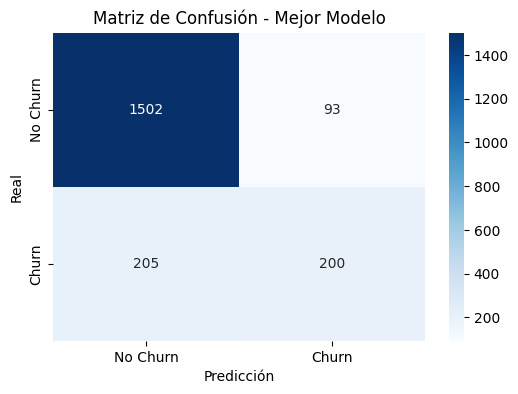

In [ ]:
import seaborn as sns
# Visualizar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Mejor Modelo")
plt.show()

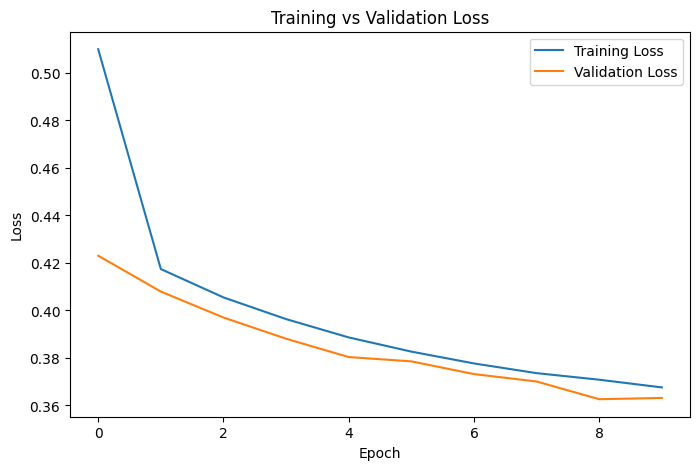

In [ ]:
#Visualizacion del entrenamiento
# Visualización del entrenamiento
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(classifier.model_.history.history['loss'], label='Training Loss')
plt.plot(classifier.model_.history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Generando el informe de clasificación completo
print("Informe de Clasificación para el Mejor Modelo:\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Informe de Clasificación para el Mejor Modelo:

              precision    recall  f1-score   support

    No Churn       0.88      0.94      0.91      1595
       Churn       0.68      0.49      0.57       405

    accuracy                           0.85      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000



Parte 4 - Evaluando, Mejorando y Ajustando la ANN

Mejorando la ANN
Regularización Dropout para reducir el sobreajuste si es necesario

In [ ]:
# Ajustando la ANN
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Dense

ModuleNotFoundError: No module named 'keras.wrappers.scikit_learn'

In [ ]:
# Instalar scikeras para KerasClassifier
!pip install scikeras

In [ ]:
# Ajustando la ANN
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
# Función para construir la ANN
def build_classifier(optimizer='adam'): # Acepta el optimizador como parámetro
    classifier = Sequential()
    classifier.add(Dense(units = 60, kernel_initializer = 'uniform', activation = 'relu', input_dim = 11))
    classifier.add(Dense(units = 60, kernel_initializer = 'uniform', activation = 'relu'))
    classifier.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
    classifier.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy']) # Compila el modelo con el optimizador dado
    return classifier

In [ ]:
# Inicializar KerasClassifier
classifier = KerasClassifier(
    model = build_classifier
)

In [ ]:
# Definición de los parámetros para la búsqueda en cuadrícula
parameters = {'batch_size': [16, 32,64],
              'epochs': [10,20,30],
              'optimizer': ['adam', 'rmsprop', 'SGD','AdamW']}
grid_search = GridSearchCV(estimator = classifier,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 10)
grid_search = grid_search.fit(X_train, y_train)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7978 - loss: 0.5155
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8242 - loss: 0.4211
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.3923
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8507 - loss: 0.3628
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3405
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8578 - loss: 0.3534
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8623 - loss: 0.3371
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8641 - loss: 0.3409
Epoch 9/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8660 - loss: 0.3292
Epoch 10/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8626 - loss: 0.3421
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7880 - loss: 0.5191
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8237 - loss: 0.4201
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8341 - loss: 0.3952
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8447 - loss: 0.3754
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8596 - loss: 0.3428
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8588 - loss: 0.3507
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8691 - loss: 0.3258
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8695 - loss: 0.3295
Epoch 9/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8651 - loss: 0.3274
Epoch 10/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8566 - loss: 0.3422
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Epoch 1/10


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7944 - loss: 0.5125
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8337 - loss: 0.4026
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8580 - loss: 0.3521
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8593 - loss: 0.3367
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8599 - loss: 0.3347
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8609 - loss: 0.3388
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8571 - loss: 0.3395
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8549 - loss: 0.3478
Epoch 9/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8634 - loss: 0.3217
Epoch 10/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8652 - loss: 0.3266
Epoch 11/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8633 - loss: 0.3279
Epoch 12/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7994 - loss: 0.5127
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8206 - loss: 0.4119
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8398 - loss: 0.3953
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8539 - loss: 0.3600
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8610 - loss: 0.3368
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8617 - loss: 0.3372
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8565 - loss: 0.3384
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8639 - loss: 0.3283
Epoch 9/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8671 - loss: 0.3283
Epoch 10/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8616 - loss: 0.3342
Epoch 11/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8646 - loss: 0.3277
Epoch 12/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy

KeyboardInterrupt: 

In [ ]:
# Mostrando los mejores parámetros y la mejor exactitud
best_parameters = grid_search.best_params_
best_accuracy = grid_search.best_score_

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:
############################################################################################
import pickle
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [ ]:
#  Imprimir historial del ajuste de parámetros y la mejor configuración
print("Mejores parámetros encontrados:", best_parameters)
print("Mejor precisión obtenida:", best_accuracy)

In [ ]:
#  Matriz de confusión
y_pred_best = grid_search.best_estimator_.predict(X_test)
y_pred_best = (y_pred_best > 0.5)
cm_best = confusion_matrix(y_test, y_pred_best)

In [ ]:
# Visualizar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Mejor Modelo")
plt.show()

In [ ]:
#  Curva ROC
y_prob = grid_search.best_estimator_.predict(X_test)  # Probabilidades de salida
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Área bajo la curva (AUC) = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Mejor Modelo')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
import os

In [ ]:
#  Guardar el modelo usando el formato correcto (.h5)
save_path = input("📂 Ingresa la ruta donde deseas GUARDAR el modelo (deja vacío para usar el directorio actual): ")
if not save_path:
    save_path = os.getcwd()

In [ ]:
model_filename = os.path.join(save_path, "best_ann_model.h5")
grid_search.best_estimator_.model.save(model_filename)  #  Usar .save() en lugar de pickle.dump()
print(f"Modelo guardado en: {model_filename}")

In [ ]:
# Cargar el modelo correctamente
load_path = input("📂 Ingresa la ruta donde deseas CARGAR el modelo (deja vacío para usar el directorio actual): ")
if not load_path:
    load_path = os.getcwd()

In [ ]:
model_filename = os.path.join(load_path, "best_ann_model.h5")

In [ ]:
# Verificar si el archivo existe
if os.path.exists(model_filename):
    loaded_model = load_model(model_filename)  #  Usar load_model() en lugar de pickle.load()
    print(f" Modelo cargado desde: {model_filename}")

    # Evaluación del modelo cargado con un nuevo ejemplo
    new_data = np.array([[0.0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])
    new_data_scaled = sc.transform(new_data)
    new_prediction = loaded_model.predict(new_data_scaled)
    new_prediction = (new_prediction > 0.5)

    print(f" Predicción del cliente nuevo: {'Churn' if new_prediction else 'No Churn'}")
else:
    print(" Error: No se encontró el archivo en la ruta especificada. Verifica la ruta e intenta de nuevo.")